In [19]:
# ============================================================
# CardioGuard Intelligence -- Feature Engineering
# ============================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_PROCESSED = os.path.join("..", "data", "processed")

### STEP 1 - Load Clean Datasets

In [2]:
demo = pd.read_csv(os.path.join(DATA_PROCESSED, "demo_clean.csv"))
bmx = pd.read_csv(os.path.join(DATA_PROCESSED, "bmx_clean.csv"))
bpx = pd.read_csv(os.path.join(DATA_PROCESSED, "bpx_clean.csv"))
glu = pd.read_csv(os.path.join(DATA_PROCESSED, "glu_clean.csv"))
ghb = pd.read_csv(os.path.join(DATA_PROCESSED, "ghb_clean.csv"))
tchol = pd.read_csv(os.path.join(DATA_PROCESSED, "tchol_clean.csv"))
hdl = pd.read_csv(os.path.join(DATA_PROCESSED, "hdl_clean.csv"))
trigly = pd.read_csv(os.path.join(DATA_PROCESSED, "trigly_clean.csv"))
smq = pd.read_csv(os.path.join(DATA_PROCESSED, "smq_clean.csv"))
paq = pd.read_csv(os.path.join(DATA_PROCESSED, "paq_clean.csv"))
bpq = pd.read_csv(os.path.join(DATA_PROCESSED, "bpq_clean.csv"))
diq = pd.read_csv(os.path.join(DATA_PROCESSED, "diq_clean.csv"))

### STEP 2 - Create Base Population

In [3]:
cardio_base = demo.copy()

print(cardio_base.shape)
cardio_base.head()

(9254, 6)


,participant_id,gender,age,ethnicity,education_level,poverty_income_ratio
0,93703.0,Female,2.0,Non-Hispanic Asian,NaN,5.00
1,93704.0,Male,2.0,Non-Hispanic White,NaN,5.00
2,93705.0,Female,66.0,Non-Hispanic Black,9th-11th grade,0.82
3,93706.0,Male,18.0,Non-Hispanic Asian,NaN,NaN
4,93707.0,Male,13.0,Other Race,NaN,1.88


### STEP 3 - Anthropometric Features

In [4]:


anthro = bmx.copy()

anthro["waist_to_height_ratio"] = (
    anthro["waist_circumference"] / anthro["height"]
)

anthro["bmi_to_waist_ratio"] = (
    anthro["bmi"] / anthro["waist_circumference"]
)

anthro = anthro[
    [
        "participant_id",
        "bmi",
        "waist_circumference",
        "weight",
        "height",
        "waist_to_height_ratio",
        "bmi_to_waist_ratio"
    ]
]

anthro.head()

,participant_id,bmi,waist_circumference,weight,height,waist_to_height_ratio,bmi_to_waist_ratio
0,93703.0,17.5,48.2,13.7,88.6,0.544018,0.363071
1,93704.0,15.7,50.0,13.9,94.2,0.530786,0.314000
2,93705.0,31.7,101.8,79.5,158.3,0.643083,0.311395
3,93706.0,21.5,79.3,66.3,175.7,0.451338,0.271122
4,93707.0,18.1,64.1,45.4,158.4,0.404672,0.282371


### STEP 4 - Cardiovascular Features

In [5]:
# STEP 5 - Cardiovascular Features

cardio = bpx.copy()

cardio["pulse_pressure"] = (
    cardio["systolic_bp"] - cardio["diastolic_bp"]
)

cardio["mean_arterial_pressure"] = (
    (2 * cardio["diastolic_bp"] + cardio["systolic_bp"]) / 3
)

cardio = cardio[
    [
        "participant_id",
        "systolic_bp",
        "diastolic_bp",
        "pulse_pressure",
        "mean_arterial_pressure"
    ]
]

cardio.head()

,participant_id,systolic_bp,diastolic_bp,pulse_pressure,mean_arterial_pressure
0,93703.0,NaN,NaN,NaN,NaN
1,93704.0,NaN,NaN,NaN,NaN
2,93705.0,NaN,NaN,NaN,NaN
3,93706.0,112.0,74.0,38.0,86.666667
4,93707.0,128.0,38.0,90.0,68.000000


### STEP 5 - Glycemic Features

In [6]:


glycemic = (
    glu
    .merge(ghb, on="participant_id", how="outer")
)

glycemic["glucose_hba1c_ratio"] = (
    glycemic["fasting_glucose"] / glycemic["hba1c"]
)

glycemic = glycemic[
    [
        "participant_id",
        "fasting_glucose",
        "hba1c",
        "glucose_hba1c_ratio"
    ]
]

glycemic.head()

,participant_id,fasting_glucose,hba1c,glucose_hba1c_ratio
0,93705.0,NaN,6.2,NaN
1,93706.0,NaN,5.2,NaN
2,93707.0,NaN,5.6,NaN
3,93708.0,122.0,6.2,19.677419
4,93709.0,NaN,6.3,NaN


### STEP 6 - Lipid Features

In [7]:


lipids = (
    tchol
    .merge(hdl, on="participant_id", how="outer")
    .merge(trigly, on="participant_id", how="outer")
)

lipids["tc_hdl_ratio"] = (
    lipids["total_cholesterol"] / lipids["hdl_cholesterol"]
)

lipids["ldl_hdl_ratio"] = (
    lipids["ldl_cholesterol"] / lipids["hdl_cholesterol"]
)

lipids["trig_hdl_ratio"] = (
    lipids["triglycerides"] / lipids["hdl_cholesterol"]
)

lipids = lipids[
    [
        "participant_id",
        "total_cholesterol",
        "hdl_cholesterol",
        "ldl_cholesterol",
        "triglycerides",
        "tc_hdl_ratio",
        "ldl_hdl_ratio",
        "trig_hdl_ratio"
    ]
]

lipids.head()

,participant_id,total_cholesterol,hdl_cholesterol,ldl_cholesterol,triglycerides,tc_hdl_ratio,ldl_hdl_ratio,trig_hdl_ratio
0,93705.0,157.0,60.0,NaN,NaN,2.616667,NaN,NaN
1,93706.0,148.0,47.0,NaN,NaN,3.148936,NaN,NaN
2,93707.0,189.0,68.0,NaN,NaN,2.779412,NaN,NaN
3,93708.0,209.0,88.0,109.0,58.0,2.375000,1.238636,0.659091
4,93709.0,176.0,65.0,NaN,NaN,2.707692,NaN,NaN


### STEP 7 - Lifestyle Features


In [8]:
# STEP 8 - Lifestyle Features

lifestyle = (
    smq[["participant_id", "smoking_status"]]
    .merge(
        paq[["participant_id", "vigorous_activity", "moderate_activity"]],
        on="participant_id",
        how="outer"
    )
)

lifestyle["smoker_flag"] = (
    lifestyle["smoking_status"] == "Yes"
).astype(int)

lifestyle["physically_active_flag"] = (
    (lifestyle["vigorous_activity"] == "Yes") |
    (lifestyle["moderate_activity"] == "Yes")
).astype(int)

lifestyle["inactive_flag"] = (
    (lifestyle["physically_active_flag"] == 0)
).astype(int)

lifestyle = lifestyle[
    [
        "participant_id",
        "smoker_flag",
        "physically_active_flag",
        "inactive_flag"
    ]
]

lifestyle.head()

,participant_id,smoker_flag,physically_active_flag,inactive_flag
0,93705.0,1,1,0
1,93706.0,0,1,0
2,93707.0,0,0,1
3,93708.0,0,1,0
4,93709.0,1,0,1


### STEP 9 - Medical History Features

In [9]:


history = (
    bpq[["participant_id", "hypertension_history", "bp_medication"]]
    .merge(
        diq[["participant_id", "diabetes_history"]],
        on="participant_id",
        how="outer"
    )
)

history["hypertension_history_flag"] = (
    history["hypertension_history"] == "Yes"
).astype(int)

history["bp_medication_flag"] = (
    history["bp_medication"] == "Yes"
).astype(int)

history["diabetes_history_flag"] = (
    history["diabetes_history"] == "Yes"
).astype(int)

history = history[
    [
        "participant_id",
        "hypertension_history_flag",
        "bp_medication_flag",
        "diabetes_history_flag"
    ]
]

history.head()

,participant_id,hypertension_history_flag,bp_medication_flag,diabetes_history_flag
0,93703.0,0,0,0
1,93704.0,0,0,0
2,93705.0,1,1,0
3,93706.0,0,0,0
4,93707.0,0,0,0


### STEP 8 - Socioeconomic Features

In [10]:


socio = demo.copy()

socio["age_65_plus_flag"] = (
    socio["age"] >= 65
).astype(int)

socio["low_income_flag"] = (
    socio["poverty_income_ratio"] < 1
).astype(int)

socio["low_education_flag"] = (
    socio["education_level"].isin([
        "Less than 9th grade",
        "9th-11th grade"
    ])
).astype(int)

socio = socio[
    [
        "participant_id",
        "age",
        "gender",
        "ethnicity",
        "education_level",
        "poverty_income_ratio",
        "age_65_plus_flag",
        "low_income_flag",
        "low_education_flag"
    ]
]

socio.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,age_65_plus_flag,low_income_flag,low_education_flag
0,93703.0,2.0,Female,Non-Hispanic Asian,NaN,5.00,0,0,0
1,93704.0,2.0,Male,Non-Hispanic White,NaN,5.00,0,0,0
2,93705.0,66.0,Female,Non-Hispanic Black,9th-11th grade,0.82,1,1,1
3,93706.0,18.0,Male,Non-Hispanic Asian,NaN,NaN,0,0,0
4,93707.0,13.0,Male,Other Race,NaN,1.88,0,0,0


### STEP 9 - Merge Feature Groups

In [12]:
# STEP 11 - Merge Predictor Feature Groups

features = (
    cardio_base[["participant_id"]]
    .merge(socio, on="participant_id", how="left")
    .merge(anthro, on="participant_id", how="left")
    .merge(cardio, on="participant_id", how="left")
    .merge(glycemic, on="participant_id", how="left")
    .merge(lipids, on="participant_id", how="left")
    .merge(lifestyle, on="participant_id", how="left")
    .merge(history, on="participant_id", how="left")
)

print(f"Feature matrix before target: {features.shape[0]:,} rows x {features.shape[1]} columns")
features.head()

Feature matrix before target: 9,254 rows x 35 columns


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,age_65_plus_flag,low_income_flag,low_education_flag,bmi,...,triglycerides,tc_hdl_ratio,ldl_hdl_ratio,trig_hdl_ratio,smoker_flag,physically_active_flag,inactive_flag,hypertension_history_flag,bp_medication_flag,diabetes_history_flag
0,93703.0,2.0,Female,Non-Hispanic Asian,NaN,5.00,0,0,0,17.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,93704.0,2.0,Male,Non-Hispanic White,NaN,5.00,0,0,0,15.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,93705.0,66.0,Female,Non-Hispanic Black,9th-11th grade,0.82,1,1,1,31.7,...,NaN,2.616667,NaN,NaN,1.0,1.0,0.0,1.0,1.0,0.0
3,93706.0,18.0,Male,Non-Hispanic Asian,NaN,NaN,0,0,0,21.5,...,NaN,3.148936,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0
4,93707.0,13.0,Male,Other Race,NaN,1.88,0,0,0,18.1,...,NaN,2.779412,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0


### STEP 12 - Create Target Construction Flags


In [13]:

target_flags = features[["participant_id"]].copy()

target_flags["obesity_target_flag"] = (
    features["bmi"] >= 30
).astype(int)

target_flags["hypertension_target_flag"] = (
    (features["systolic_bp"] >= 130) |
    (features["diastolic_bp"] >= 80) |
    (features["hypertension_history_flag"] == 1) |
    (features["bp_medication_flag"] == 1)
).astype(int)

target_flags["diabetes_target_flag"] = (
    (features["fasting_glucose"] >= 126) |
    (features["hba1c"] >= 6.5) |
    (features["diabetes_history_flag"] == 1)
).astype(int)

target_flags["dyslipidemia_target_flag"] = (
    (features["total_cholesterol"] >= 200) |
    (features["ldl_cholesterol"] >= 130) |
    (features["hdl_cholesterol"] < 40) |
    (features["triglycerides"] >= 150)
).astype(int)

target_flags["target_risk_count"] = (
    target_flags["obesity_target_flag"] +
    target_flags["hypertension_target_flag"] +
    target_flags["diabetes_target_flag"] +
    target_flags["dyslipidemia_target_flag"]
)

target_flags["high_risk_flag"] = (
    target_flags["target_risk_count"] >= 3
).astype(int)

target_flags.head()

,participant_id,obesity_target_flag,hypertension_target_flag,diabetes_target_flag,dyslipidemia_target_flag,target_risk_count,high_risk_flag
0,93703.0,0,0,0,0,0,0
1,93704.0,0,0,0,0,0,0
2,93705.0,1,1,0,0,2,0
3,93706.0,0,0,0,0,0,0
4,93707.0,0,0,0,0,0,0


# STEP 13 - Attach Target Only

In [14]:

features = features.merge(
    target_flags[["participant_id", "high_risk_flag"]],
    on="participant_id",
    how="left"
)

print(features["high_risk_flag"].value_counts(normalize=True).mul(100).round(2))

high_risk_flag
0    86.51
1    13.49
Name: proportion, dtype: float64


### STEP 14 - Remove Medical History Leakage Columns

In [15]:
# Because medical history flags were used to help define the target, 
# #we remove them from the final modelling dataset.

# This prevents the model from learning the target rule directly.


LEAKAGE_COLS = [
    "hypertension_history_flag",
    "bp_medication_flag",
    "diabetes_history_flag"
]

features = features.drop(
    columns=[col for col in LEAKAGE_COLS if col in features.columns]
)


### STEP 15 - Handle Infinite Values

In [16]:
# Some ratio features may create infinite values if the denominator is zero. 
# These are converted to missing values. 
# The modelling pipeline will handle missing values later.


features = features.replace([np.inf, -np.inf], np.nan)

### STEP 16 - Final Validation

In [17]:

print(f"Final modelling feature matrix: {features.shape[0]:,} rows x {features.shape[1]} columns")
print(f"Null count: {features.isnull().sum().sum()}")

print("\nTarget distribution:")
print(features["high_risk_flag"].value_counts(normalize=True).mul(100).round(2))

Final modelling feature matrix: 9,254 rows x 33 columns
Null count: 82860

Target distribution:
high_risk_flag
0    86.51
1    13.49
Name: proportion, dtype: float64


 ###  STEP 17 - Correlation Check With Target


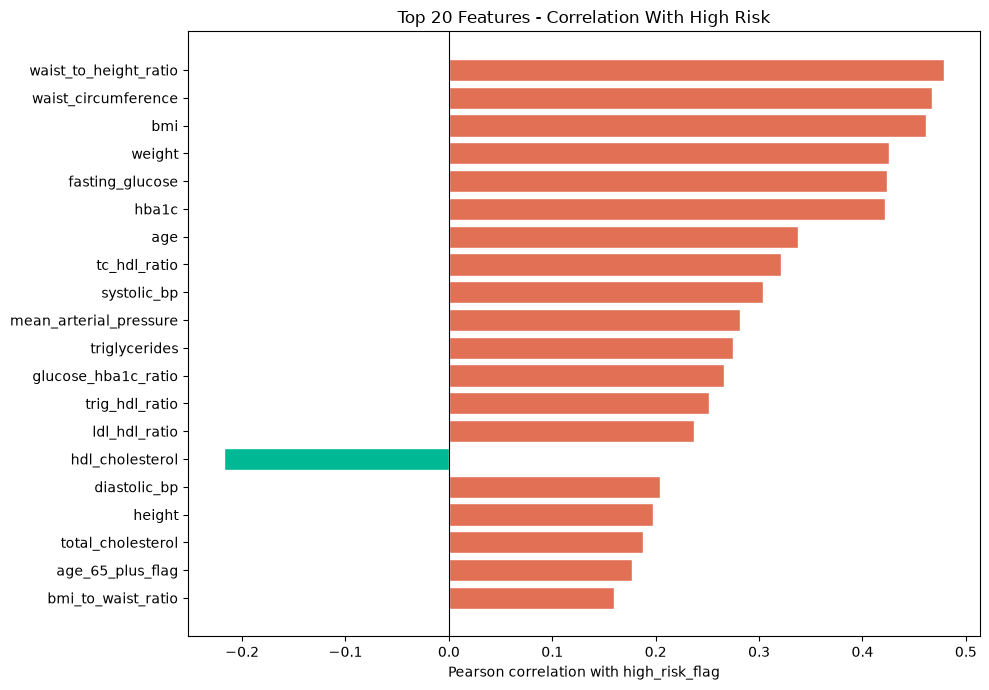


Top 10:
waist_to_height_ratio     0.479
waist_circumference       0.467
bmi                       0.461
weight                    0.426
fasting_glucose           0.423
hba1c                     0.422
age                       0.338
tc_hdl_ratio              0.321
systolic_bp               0.304
mean_arterial_pressure    0.281


In [20]:


feature_cols = [
    c for c in features.columns
    if c not in ["participant_id", "high_risk_flag"]
]

corr = (
    features[feature_cols + ["high_risk_flag"]]
    .corr(numeric_only=True)["high_risk_flag"]
    .drop("high_risk_flag")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))

top20 = corr.head(20)

colors = [
    "#E17055" if v > 0 else "#00B894"
    for v in top20.values
]

ax.barh(
    top20.index[::-1],
    top20.values[::-1],
    color=colors[::-1],
    edgecolor="white"
)

ax.axvline(0, color="black", linewidth=0.8)

ax.set(
    title="Top 20 Features - Correlation With High Risk",
    xlabel="Pearson correlation with high_risk_flag"
)

plt.tight_layout()
plt.show()

print("\nTop 10:")
print(corr.head(10).round(3).to_string())

###  STEP 18 - Save Final  Feature Dataset


In [21]:

out_path = os.path.join(
    DATA_PROCESSED,
    "cardioguard_model_features.csv"
)

features.to_csv(out_path, index=False)

print(f"Saved cardioguard_model_features.csv")
print(f"Rows: {features.shape[0]:,}")
print(f"Columns: {features.shape[1]:,}")
print(f"Path: {os.path.abspath(out_path)}")

print("\nAll columns:")
for i, col in enumerate(features.columns, 1):
    print(f"{i:>2}. {col}")

Saved cardioguard_model_features.csv
Rows: 9,254
Columns: 33
Path: c:\CardioGuard_Project\data\processed\cardioguard_model_features.csv

All columns:
 1. participant_id
 2. age
 3. gender
 4. ethnicity
 5. education_level
 6. poverty_income_ratio
 7. age_65_plus_flag
 8. low_income_flag
 9. low_education_flag
10. bmi
11. waist_circumference
12. weight
13. height
14. waist_to_height_ratio
15. bmi_to_waist_ratio
16. systolic_bp
17. diastolic_bp
18. pulse_pressure
19. mean_arterial_pressure
20. fasting_glucose
21. hba1c
22. glucose_hba1c_ratio
23. total_cholesterol
24. hdl_cholesterol
25. ldl_cholesterol
26. triglycerides
27. tc_hdl_ratio
28. ldl_hdl_ratio
29. trig_hdl_ratio
30. smoker_flag
31. physically_active_flag
32. inactive_flag
33. high_risk_flag
